In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import joblib

In [81]:
import sys
print(sys.executable)


/Users/aashshah/Documents/coding/.venv/bin/python


In [82]:

#setting plot style 
plt.style.use("default")

#oad the data 
data_path = "../data/survey_lung_cancer.csv"  # adjust if needed
df = pd.read_csv(data_path)

df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [83]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [84]:
#eda shape and statistics
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nSummary statistics:")
display(df.describe(include="all"))

Shape: (309, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   gender                 309 non-null    object
 1   age                    309 non-null    int64 
 2   smoking                309 non-null    int64 
 3   yellow_fingers         309 non-null    int64 
 4   anxiety                309 non-null    int64 
 5   peer_pressure          309 non-null    int64 
 6   chronic_disease        309 non-null    int64 
 7   fatigue                309 non-null    int64 
 8   allergy                309 non-null    int64 
 9   wheezing               309 non-null    int64 
 10  alcohol_consuming      309 non-null    int64 
 11  coughing               309 non-null    int64 
 12  shortness_of_breath    309 non-null    int64 
 13  swallowing_difficulty  309 non-null    int64 
 14  chest_pain             309 non-null    int64 
 15 

,gender,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic_disease,fatigue,allergy,wheezing,alcohol_consuming,coughing,shortness_of_breath,swallowing_difficulty,chest_pain,lung_cancer
count,309,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES
freq,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,270
mean,NaN,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634,NaN
std,NaN,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588,NaN
min,NaN,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,NaN,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
50%,NaN,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,NaN
75%,NaN,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,NaN


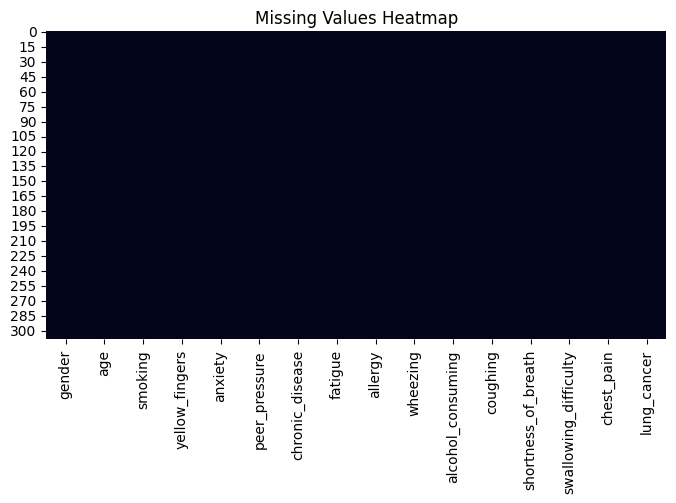

In [85]:
#heatmap of missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [86]:
#target distribution (assuming column name is 'LUNG_CANCER')
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='LUNG_CANCER')
plt.title("LUNG_CANCER Label Distribution")
plt.show()

ValueError: Could not interpret value `LUNG_CANCER` for `x`. An entry with this name does not appear in `data`.

<Figure size 500x400 with 0 Axes>

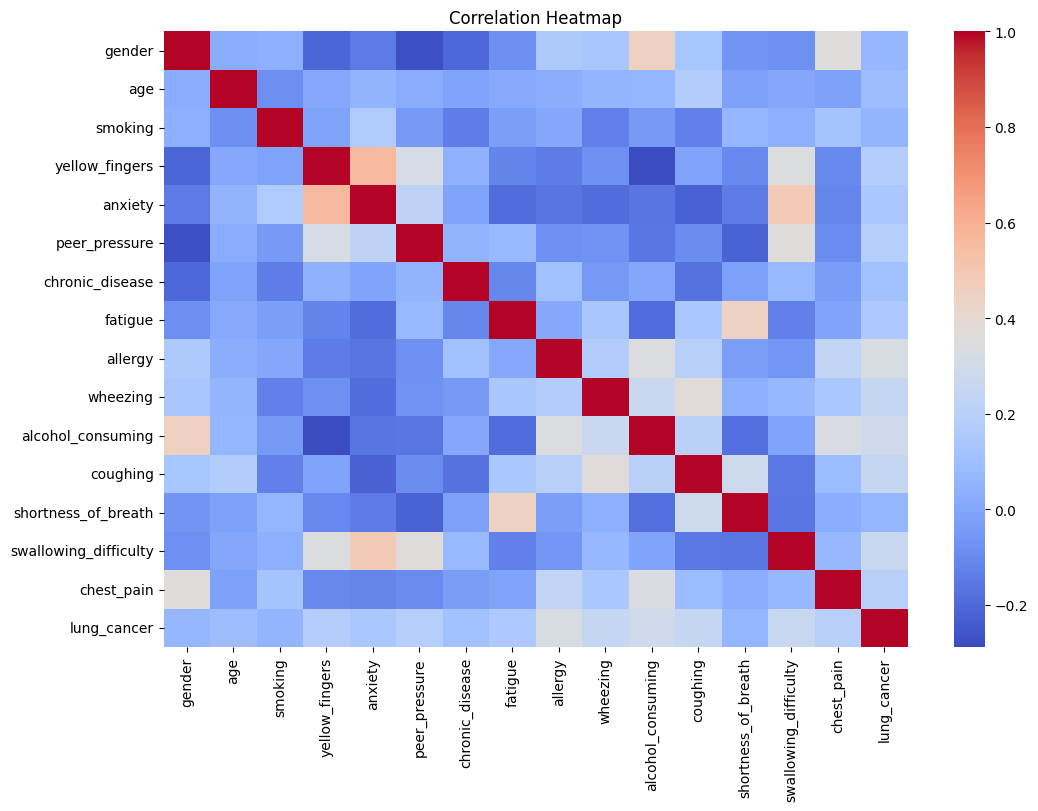

In [87]:
#correlation heatmap we also convert the yes no to numeric data 
df_corr = df.copy()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = df_corr[col].astype('category').cat.codes

#display data graphically
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [88]:
#preprocessing the data by encoding the data 
df_proc = df.copy()
label_encoders = {}
for col in df_proc.columns:
    if df_proc[col].dtype == 'object':
        le = LabelEncoder()
        df_proc[col] = le.fit_transform(df_proc[col])
        label_encoders[col] = le

In [89]:
#split the data by seperating the features and target 
x = df_proc.drop('LUNG_CANCER', axis=1)
y = df_proc['LUNG_CANCER']

#training and testing the split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
    )

KeyError: "['LUNG_CANCER'] not found in axis"

In [90]:
#scaling the features 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

((247, 15), (62, 15))

In [91]:
#model benchmarking

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df.sort_values("Accuracy", ascending=False)


,Model,Accuracy
4,Decision Tree,0.919355
5,Random Forest,0.919355
0,Logistic Regression,0.903226
6,XGBoost,0.887097
2,KNN,0.870968
1,SVM,0.854839
3,Naive Bayes,0.854839


In [92]:
#training the best model 
best_model = RandomForestClassifier(random_state=42)
best_model.fit(x_train_scaled, y_train)
y_pred = best_model.predict(x_test_scaled)

Accuracy: 91.94%

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.75      0.71         8
           1       0.96      0.94      0.95        54

    accuracy                           0.92        62
   macro avg       0.81      0.85      0.83        62
weighted avg       0.92      0.92      0.92        62



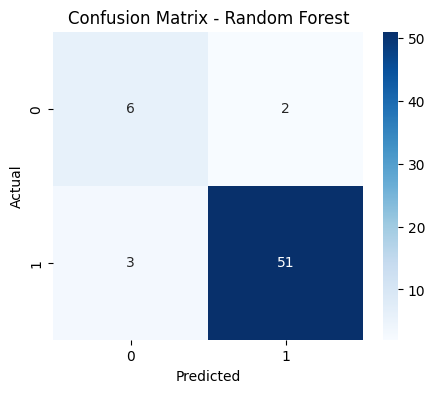

In [93]:
#evaluation
print("Accuracy:", f"{accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [94]:
#saving the model and scalar to the artifacts 
joblib.dump(best_model, "../artifacts/best_model.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")
print("Saved best_model.pkl and scaler.pkl in artifacts/")

Saved best_model.pkl and scaler.pkl in artifacts/


In [95]:
#SHAP explainability
import shap
explain = shap.TreeExplainer(best_model)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x.columns)
shap_values = explain.shap_values(x_test_scaled_df)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [96]:
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
else:
    shap_values_to_use = shap_values

print("SHAP values shape:", shap_values_to_use.shape)
print("x_test shape:", x_test_scaled_df.shape)
if shap_values_to_use.shape[1] == x_test_scaled_df.shape[1] + 1:
    shap_values_to_use = shap_values_to_use[:, :-1]

SHAP values shape: (62, 15, 2)
x_test shape: (62, 15)


In [97]:
#summary plot
shap.summary_plot(shap_values_to_use, x_test_scaled_df, feature_names=x.columns)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [98]:
!pip install optuna mlflow


In [99]:
#hyperparameter tuning: rf with optuna
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

def rf_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 400)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        bootstrap=bootstrap,
        random_state=42
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, x_train_scaled, y_train, cv=cv, scoring="accuracy")
    return scores.mean()

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(rf_objective, n_trials=30)

best_rf_params = study_rf.best_params
best_rf_params


[I 2025-11-18 19:26:37,866] A new study created in memory with name: no-name-d45d2393-0306-4043-8b40-4099fc091228
[I 2025-11-18 19:26:38,265] Trial 0 finished with value: 0.874530612244898 and parameters: {'n_estimators': 250, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True}. Best is trial 0 with value: 0.874530612244898.
[I 2025-11-18 19:26:38,502] Trial 1 finished with value: 0.9150204081632654 and parameters: {'n_estimators': 190, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 3, 'bootstrap': False}. Best is trial 1 with value: 0.9150204081632654.
[I 2025-11-18 19:26:38,896] Trial 2 finished with value: 0.9191020408163265 and parameters: {'n_estimators': 332, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}. Best is trial 2 with value: 0.9191020408163265.
[I 2025-11-18 19:26:39,478] Trial 3 finished with value: 0.8948571428571428 and parameters: {'n_estimators': 370, 'max_depth': 4, 'min_samples_split'

{'n_estimators': 332,
 'max_depth': 15,
 'min_samples_split': 8,
 'min_samples_leaf': 2,
 'bootstrap': False}

Tuned RF Accuracy: 0.8548387096774194
              precision    recall  f1-score   support

           0       0.40      0.25      0.31         8
           1       0.89      0.94      0.92        54

    accuracy                           0.85        62
   macro avg       0.65      0.60      0.61        62
weighted avg       0.83      0.85      0.84        62



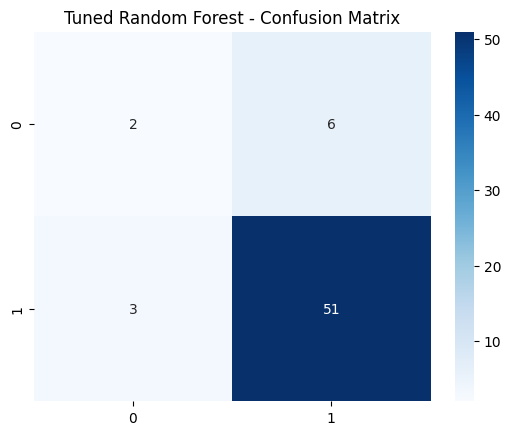

In [100]:
#trained and evaluating the rf
best_rf = RandomForestClassifier(**best_rf_params, random_state=42)
best_rf.fit(x_train_scaled, y_train)

rf_pred = best_rf.predict(x_test_scaled)

print("Tuned RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [101]:
#hyperparamter tuning of xgboost with optuna 

from xgboost import XGBClassifier

def xgb_objective(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "eval_metric": "logloss",
        "use_label_encoder": False
    }

    model = XGBClassifier(**param)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, x_train_scaled, y_train, cv=cv, scoring="accuracy")
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgb_objective, n_trials=30)

best_xgb_params = study_xgb.best_params
best_xgb_params


[I 2025-11-18 19:26:49,106] A new study created in memory with name: no-name-fd45582d-d962-432e-a300-c1d626038125
[I 2025-11-18 19:26:49,204] Trial 0 finished with value: 0.9231836734693879 and parameters: {'max_depth': 3, 'learning_rate': 0.03221391657568392, 'n_estimators': 122, 'subsample': 0.9469037598101189, 'colsample_bytree': 0.803867268519575, 'gamma': 1.467699392724432}. Best is trial 0 with value: 0.9231836734693879.
[I 2025-11-18 19:26:49,294] Trial 1 finished with value: 0.8947755102040817 and parameters: {'max_depth': 3, 'learning_rate': 0.020121241775955947, 'n_estimators': 130, 'subsample': 0.7805457282006363, 'colsample_bytree': 0.6512745854468134, 'gamma': 2.552190158716793}. Best is trial 0 with value: 0.9231836734693879.
[I 2025-11-18 19:26:49,469] Trial 2 finished with value: 0.9149387755102041 and parameters: {'max_depth': 10, 'learning_rate': 0.2559454882360533, 'n_estimators': 189, 'subsample': 0.8260983543544775, 'colsample_bytree': 0.6133981050433064, 'gamma': 

{'max_depth': 5,
 'learning_rate': 0.07523508327357975,
 'n_estimators': 250,
 'subsample': 0.5199725892635587,
 'colsample_bytree': 0.8825889520201463,
 'gamma': 0.994730398460455}

Tuned XGB Accuracy: 0.8870967741935484
              precision    recall  f1-score   support

           0       0.57      0.50      0.53         8
           1       0.93      0.94      0.94        54

    accuracy                           0.89        62
   macro avg       0.75      0.72      0.73        62
weighted avg       0.88      0.89      0.88        62



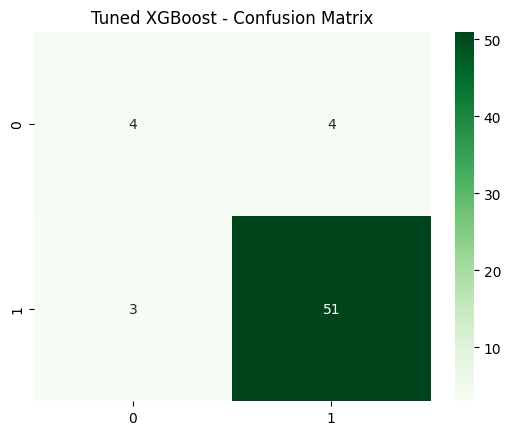

In [102]:
#trianing and evaluating tuned xgboost 
best_xgb = XGBClassifier(**best_xgb_params, eval_metric="logloss", use_label_encoder=False)
best_xgb.fit(x_train_scaled, y_train)

xgb_pred = best_xgb.predict(x_test_scaled)

print("Tuned XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

xgb_cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

In [103]:
#cross vlaidation scores for tuned models 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(best_rf, x_train_scaled, y_train, cv=cv, scoring="accuracy")
xgb_cv_scores = cross_val_score(best_xgb, x_train_scaled, y_train, cv=cv, scoring="accuracy")

cv_results = pd.DataFrame({
    "Model": ["Tuned Random Forest", "Tuned XGBoost"],
    "Mean Accuracy": [rf_cv_scores.mean(), xgb_cv_scores.mean()],
    "Std Dev": [rf_cv_scores.std(), xgb_cv_scores.std()]
})

cv_results

,Model,Mean Accuracy,Std Dev
0,Tuned Random Forest,0.923184,0.034226
1,Tuned XGBoost,0.931184,0.027380


In [104]:
#feature importance
#rf
importances_rf = pd.Series(best_rf.feature_importances_, index=x.columns).sort_values(ascending=False)
importances_rf.plot(kind="bar", figsize=(10,5), title="Random Forest Feature Importance")
plt.show()
#xgboost
importances_xgb = pd.Series(best_xgb.feature_importances_, index=x.columns).sort_values(ascending=False)
importances_xgb.plot(kind="bar", figsize=(10,5), title="XGBoost Feature Importance")
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

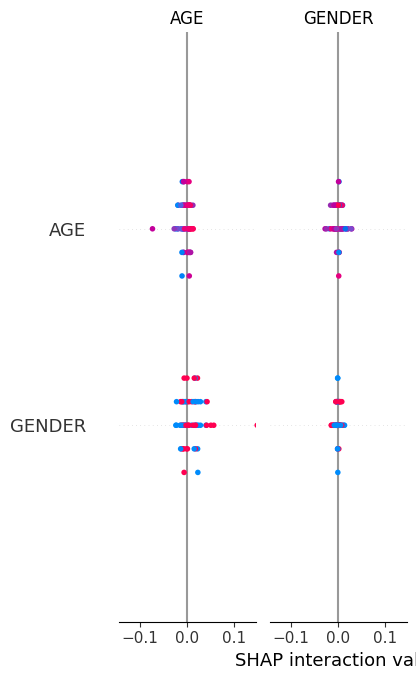

In [ ]:
#shap for best tuned model 
import shap
explainer = shap.TreeExplainer(best_rf)
x_test_df = pd.DataFrame(x_test_scaled, columns=x.columns)
shap_values = explainer.shap_values(x_test_df)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

if shap_values.shape[1] == x_test_df.shape[1] + 1:
    shap_values = shap_values[:, :-1]

shap.summary_plot(shap_values, x_test_df, feature_names=x.columns)

In [ ]:
#tracking the ml flow
import mlflow
import mlflow.sklearn

mlflow.set_experiment("lung_cancer_project")

with mlflow.start_run(run_name="Tuned Random Forest"):
    mlflow.log_params(best_rf_params)
    mlflow.log_metric("accuracy", accuracy_score(y_test, rf_pred))
    mlflow.sklearn.log_model(best_rf, "rf_model")

with mlflow.start_run(run_name="Tuned XGBoost"):
    mlflow.log_params(best_xgb_params)
    mlflow.log_metric("accuracy", accuracy_score(y_test, xgb_pred))
    mlflow.sklearn.log_model(best_xgb, "xgb_model")

print("MLflow logging complete.")

2025/11/18 16:54:13 INFO mlflow.tracking.fluent: Experiment with name 'lung_cancer_project' does not exist. Creating a new experiment.
2025/11/18 16:54:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/18 16:54:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/18 16:54:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/18 16:54:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow logging complete.


In [ ]:
joblib.dump(best_rf, "../artifacts/tuned_rf.pkl")
joblib.dump(best_xgb, "../artifacts/tuned_xgb.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")


['../artifacts/scaler.pkl']

In [ ]:
#hyperparameter tunig for optuna and 5 fold cv
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import json
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#save
def save_json(path, data):
    with open(path, 'w') as f:
        json.dump(data, f, indent=4)

In [ ]:
#k fold 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

x = x_train_scaled
y = y_train

In [ ]:
#random forest tuning
def rf_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 1000)
    max_depth = trial.suggest_int("max_depth", 3, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        bootstrap=bootstrap,
        random_state=42
    )

    cv_score = cross_val_score(model, x, y, cv=skf, scoring="accuracy").mean()
    return cv_score

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=30)

rf_best_params = rf_study.best_params
save_json("../tuning/rf_best_params.json", rf_best_params)

print("Best RF Params:", rf_best_params)


[I 2025-11-18 17:45:23,807] A new study created in memory with name: no-name-fc6ca312-f3f7-41b9-ad01-1063452ff9bb
[I 2025-11-18 17:45:24,236] Trial 0 finished with value: 0.8947755102040817 and parameters: {'n_estimators': 322, 'max_depth': 16, 'min_samples_split': 15, 'min_samples_leaf': 9, 'bootstrap': False}. Best is trial 0 with value: 0.8947755102040817.
[I 2025-11-18 17:45:25,312] Trial 1 finished with value: 0.8866938775510205 and parameters: {'n_estimators': 675, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 5, 'bootstrap': True}. Best is trial 0 with value: 0.8947755102040817.
[I 2025-11-18 17:45:25,599] Trial 2 finished with value: 0.9068571428571428 and parameters: {'n_estimators': 179, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 1, 'bootstrap': True}. Best is trial 2 with value: 0.9068571428571428.
[I 2025-11-18 17:45:25,987] Trial 3 finished with value: 0.8947755102040817 and parameters: {'n_estimators': 331, 'max_depth': 30, 'min_samples_spl

Best RF Params: {'n_estimators': 553, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 1, 'bootstrap': False}


In [ ]:
import os
import os

if not os.path.exists("tuning"):
    os.makedirs("tuning")

os.listdir()


['mlruns', 'tuning', 'lung_cancer_model.ipynb']

In [ ]:
def xgb_objective(trial):
    params = {
        "eta": trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
    }

    model = xgb.XGBClassifier(**params, random_state=42, tree_method="hist")

    cv_score = cross_val_score(model, x, y, cv=skf, scoring="accuracy").mean()
    return cv_score

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=30)

xgb_best_params = xgb_study.best_params
save_json("../tuning/xgb_best_params.json", xgb_best_params)

print("Best XGB Params:", xgb_best_params)


[I 2025-11-18 17:45:40,219] A new study created in memory with name: no-name-d41743e5-43fe-458d-85f1-f848555f5295
[I 2025-11-18 17:45:40,298] Trial 0 finished with value: 0.9067755102040816 and parameters: {'eta': 0.06640036564859107, 'max_depth': 4, 'subsample': 0.6195812871043145, 'colsample_bytree': 0.8216627283454274, 'min_child_weight': 4}. Best is trial 0 with value: 0.9067755102040816.
[I 2025-11-18 17:45:40,374] Trial 1 finished with value: 0.9110204081632652 and parameters: {'eta': 0.20577060674966094, 'max_depth': 19, 'subsample': 0.8295442300119178, 'colsample_bytree': 0.831017524675779, 'min_child_weight': 1}. Best is trial 1 with value: 0.9110204081632652.
[I 2025-11-18 17:45:40,446] Trial 2 finished with value: 0.9231836734693879 and parameters: {'eta': 0.19406269998523282, 'max_depth': 7, 'subsample': 0.8504132215222175, 'colsample_bytree': 0.4980122510934925, 'min_child_weight': 2}. Best is trial 2 with value: 0.9231836734693879.
[I 2025-11-18 17:45:40,507] Trial 3 fini

Best XGB Params: {'eta': 0.07585056369512876, 'max_depth': 8, 'subsample': 0.5866723675747674, 'colsample_bytree': 0.5551122504936103, 'min_child_weight': 1}


In [ ]:
def svm_objective(trial):
    C = trial.suggest_float("C", 0.1, 10.0)
    gamma = trial.suggest_float("gamma", 1e-4, 1e-1, log=True)
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"])

    model = SVC(C=C, gamma=gamma, kernel=kernel)

    cv_score = cross_val_score(model, x, y, cv=skf, scoring="accuracy").mean()
    return cv_score

svm_study = optuna.create_study(direction="maximize")
svm_study.optimize(svm_objective, n_trials=30)

svm_best_params = svm_study.best_params
save_json("../tuning/svm_best_params.json", svm_best_params)

print("Best SVM Params:", svm_best_params)


[I 2025-11-18 17:45:42,137] A new study created in memory with name: no-name-d8dba249-1654-4a81-9903-2c5300dcca51
[I 2025-11-18 17:45:42,147] Trial 0 finished with value: 0.9111020408163265 and parameters: {'C': 4.501468930737544, 'gamma': 0.0691113635096885, 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.9111020408163265.
[I 2025-11-18 17:45:42,152] Trial 1 finished with value: 0.9069387755102041 and parameters: {'C': 1.9691406137902498, 'gamma': 0.0117643039625702, 'kernel': 'rbf'}. Best is trial 0 with value: 0.9111020408163265.
[I 2025-11-18 17:45:42,157] Trial 2 finished with value: 0.9150204081632654 and parameters: {'C': 0.8934444286825376, 'gamma': 0.036889785660567456, 'kernel': 'rbf'}. Best is trial 2 with value: 0.9150204081632654.
[I 2025-11-18 17:45:42,163] Trial 3 finished with value: 0.9149387755102041 and parameters: {'C': 4.532228651554158, 'gamma': 0.011558945848478601, 'kernel': 'sigmoid'}. Best is trial 2 with value: 0.9150204081632654.
[I 2025-11-18 17:45:42,1

Best SVM Params: {'C': 9.961172098942914, 'gamma': 0.04418398830131178, 'kernel': 'sigmoid'}


In [ ]:
combined_results = {
    "Random Forest": rf_best_params,
    "XGBoost": xgb_best_params,
    "SVM": svm_best_params
}

save_json("../tuning/cv_results.json", combined_results)

print("Tuning completed! Results saved in /tuning/")

Tuning completed! Results saved in /tuning/


In [ ]:
with open("../tuning/rf_best_params.json", "r") as f:
    rf_best = json.load(f)

with open("../tuning/xgb_best_params.json", "r") as f:
    xgb_best = json.load(f)

with open("../tuning/svm_best_params.json", "r") as f:
    svm_best = json.load(f)


In [ ]:
#retrain models 
#rf
rf_final = RandomForestClassifier(**rf_best, random_state=42)
rf_final.fit(x_train_scaled, y_train)

#xgboost 
xgb_final = xgb.XGBClassifier(**xgb_best, random_state=42, tree_method="hist")
xgb_final.fit(x_train_scaled, y_train)

#svm
svm_final = SVC(**svm_best, probability=True)
svm_final.fit(x_train_scaled, y_train)

,C,9.961172098942914
,kernel,'sigmoid'
,degree,3
,gamma,0.04418398830131178
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model, name):
    preds = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results = []
results.append(evaluate_model(rf_final, "Random Forest"))
results.append(evaluate_model(xgb_final, "XGBoost"))
results.append(evaluate_model(svm_final, "SVM"))

results_df = pd.DataFrame(results)
results_df


===== Random Forest =====
Accuracy: 0.8870967741935484
Precision: 0.9272727272727272
Recall: 0.9444444444444444
F1 Score: 0.9357798165137615
Confusion Matrix:
[[ 4  4]
 [ 3 51]]

===== XGBoost =====
Accuracy: 0.9032258064516129
Precision: 0.9285714285714286
Recall: 0.9629629629629629
F1 Score: 0.9454545454545454
Confusion Matrix:
[[ 4  4]
 [ 2 52]]

===== SVM =====
Accuracy: 0.9032258064516129
Precision: 0.9285714285714286
Recall: 0.9629629629629629
F1 Score: 0.9454545454545454
Confusion Matrix:
[[ 4  4]
 [ 2 52]]


,model,accuracy,precision,recall,f1
0,Random Forest,0.887097,0.927273,0.944444,0.935780
1,XGBoost,0.903226,0.928571,0.962963,0.945455
2,SVM,0.903226,0.928571,0.962963,0.945455


In [ ]:
#select best model 
best_model_name = results_df.sort_values(by="f1", ascending=False).iloc[0]["model"]
print("\nBest model selected:", best_model_name)

if best_model_name == "Random Forest":
    best_model = rf_final
elif best_model_name == "XGBoost":
    best_model = xgb_final
else:
    best_model = svm_final


Best model selected: XGBoost


In [ ]:
joblib.dump(best_model, "../artifacts/final_model.pkl")
joblib.dump(scaler, "../artifacts/final_scaler.pkl")

joblib.dump(rf_final, "../artifacts/rf_final.pkl")
joblib.dump(xgb_final, "../artifacts/xgb_final.pkl")
joblib.dump(svm_final, "../artifacts/svm_final.pkl")

print("Models saved to artifacts/ folder.")

Models saved to artifacts/ folder.
